In [63]:
import numpy as np
import pandas as pd
import scipy as sp
import seaborn as sns
import matplotlib.pyplot as plt
from math import e, pi, sqrt, log
from random import random as rand
import ipywidgets as ipw

<h1>Zadanie 1</h1>
<h3>e), f), g)</h3>

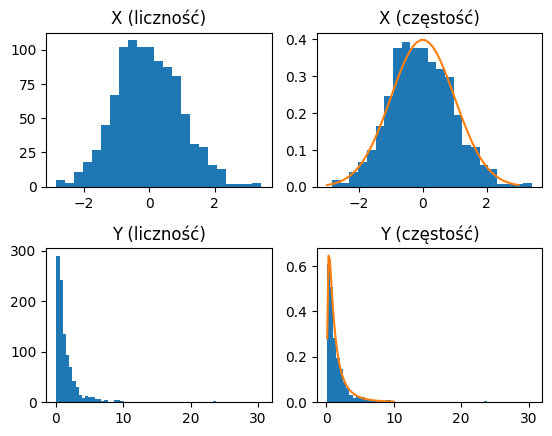

In [64]:
x = sp.stats.norm.rvs(size=1000) #dane
y = e**x

fig, ax = plt.subplots(2,2)

ax[0][0].hist(x, bins="auto")
ax[0][0].set_title("X (liczność)")

ax[0][1].hist(x, bins="auto", density=True) #histogram
ax[0][1].plot(np.linspace(-3,3), sp.stats.norm.pdf(np.linspace(-3,3))) #gęstość
ax[0][1].set_title("X (częstość)")

ax[1][0].hist(y, bins="auto")
ax[1][0].set_title("Y (liczność)")

ax[1][1].hist(y, bins="auto", density=True)
def fy(t):
    return (1/t)*(1/sqrt(2*pi))*e**(-(log(t)**2)/2) #gęstość policzona na zajęciach
ax[1][1].plot(np.linspace(0.1,10), [fy(t) for t in np.linspace(0.1,10)])
ax[1][1].set_title("Y (częstość)")

plt.subplots_adjust(hspace=0.4)
plt.show()

<h3>h)</h3>

<Axes: ylabel='Density'>

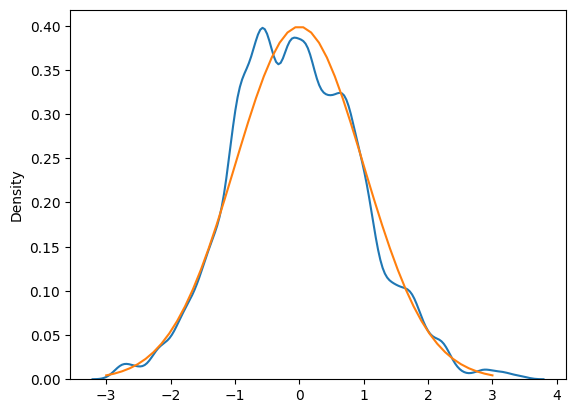

In [65]:
sns.kdeplot(x, bw_adjust=0.5) #estymator jądrowy - gęstość empiryczna
sns.lineplot(x=np.linspace(-3,3), y=sp.stats.norm.pdf(np.linspace(-3,3)))

<h3>i)</h3>

In [66]:
print(f"skośność: {sp.stats.skew(x)}, {sp.stats.skew(y)}")
print(f"kurtoza: {sp.stats.kurtosis(x, fisher=False)}, {sp.stats.kurtosis(y, fisher=False)}")

skośność: 0.19180699034608406, 5.479374694946636
kurtoza: 3.0868391380179263, 47.81935652056514


<h1>Zadanie 2</h1>
<h3>c)</h3>

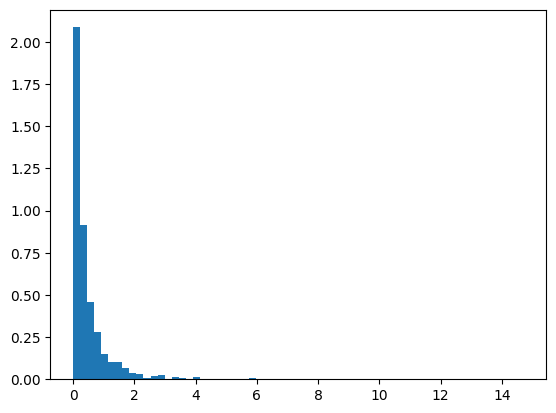

In [67]:
def pareto(alfa, lamb):
    return (lamb/(1-rand())**(1/alfa))-lamb

alfa, lamb = 3, 1
p = np.array([pareto(alfa, lamb) for _ in range(1000)])
plt.hist(p, bins="auto", density=True)
plt.show()

<h3>d)</h3>

<Axes: ylabel='Proportion'>

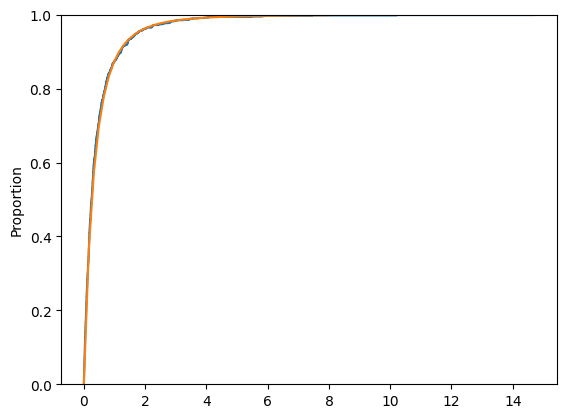

In [68]:
sns.ecdfplot(p) #empiryczna dystrybuanta
sns.lineplot(x=np.linspace(0,8), y=1-(lamb/(lamb+np.linspace(0,8)))**alfa)

<h3>e)</h3>

<Axes: ylabel='Density'>

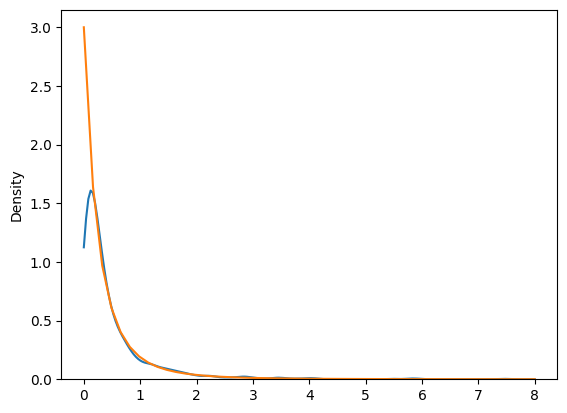

In [69]:
sns.kdeplot(p, clip=(0,8), bw_adjust=0.5) #czemu to nie działa?
sns.lineplot(x=np.linspace(0,8), y=alfa*lamb**alfa/(lamb + np.linspace(0,8))**(alfa+1))

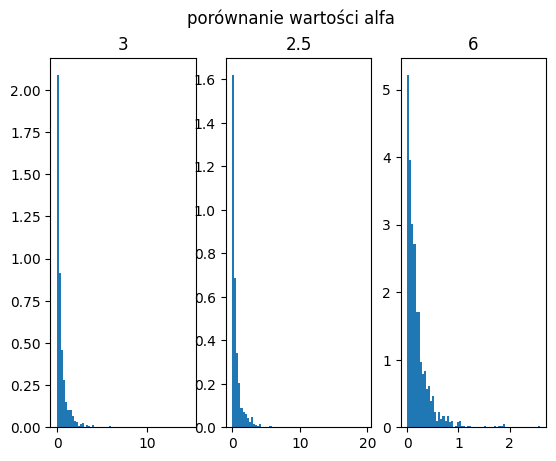

In [85]:
fig, ax = plt.subplots(ncols=3)
ax[0].hist(p, bins="auto", density=True)
ax[0].set_title("3")
ax[1].hist([pareto(2.5, 1) for _ in range(1000)], bins="auto", density=True)
ax[1].set_title("2.5")
ax[2].hist([pareto(6, 1) for _ in range(1000)], bins="auto", density=True)
ax[2].set_title("6")
plt.suptitle("porównanie wartości alfa")
plt.show()

In [ ]:
def update(a, l):
    plt.hist([pareto(a, l) for _ in range(10000)], bins="auto", density=True)
    plt.show()

ipw.interact(
    update,
    a=ipw.FloatSlider(value=2,min=0.0,max=10.0,step=0.01,description="alfa"),
    l=ipw.FloatSlider(value=1,min=0.0,max=20.0,step=0.01,description="lambda")
);

interactive(children=(FloatSlider(value=2.0, description='alfa', max=10.0, step=0.01), FloatSlider(value=1.0, …

<h1>Zadanie 3</h1>
<h3>c)</h3>

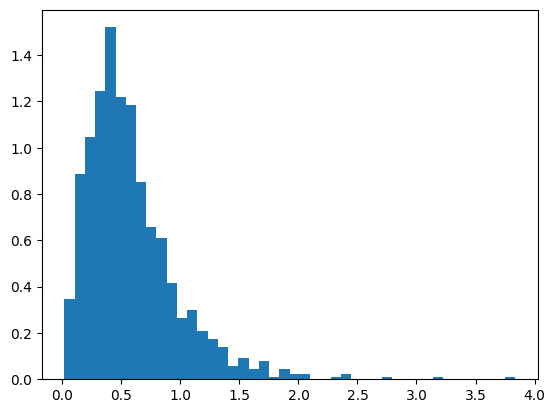

In [72]:
tau = 2
b = p**(1/tau)
plt.hist(b, bins="auto", density=True)
plt.show()

<h3>d)</h3>

<Axes: ylabel='Density'>

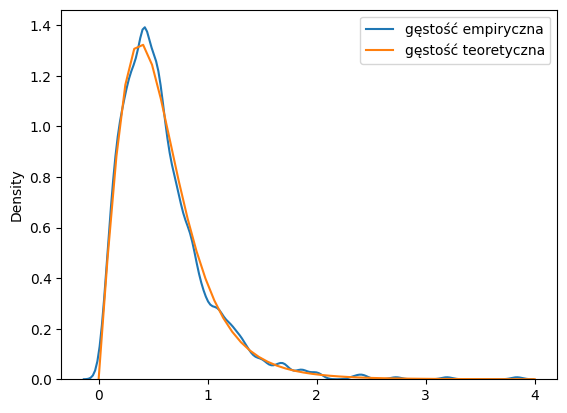

In [79]:
sns.kdeplot(b, bw_adjust=0.5, label="gęstość empiryczna")
#sns.lineplot(x=np.linspace(0,4), y=[alfa*tau*(lamb**alfa)*(t**(tau-1)/(lamb+t**tau)**(alfa+1)) for t in np.linspace(0,4)])
sns.lineplot(x=np.linspace(0,4), y=alfa*tau*(lamb**alfa)*(np.linspace(0,4)**(tau-1)/(lamb+np.linspace(0,4)**tau)**(alfa+1)), label="gęstość teoretyczna")

<h3>e)</h3>

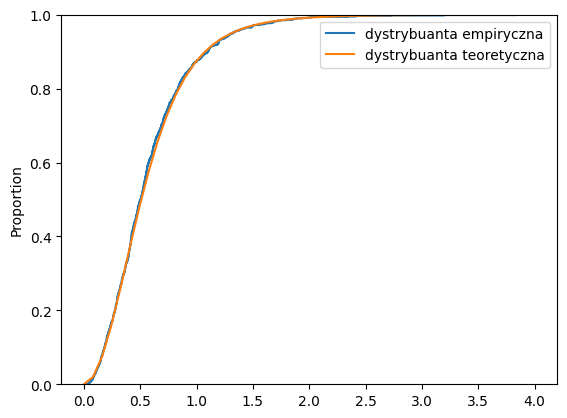

In [77]:
sns.ecdfplot(b, label="dystrybuanta empiryczna")
sns.lineplot(x=np.linspace(0,4), y=1-(lamb/(lamb+np.linspace(0,4)**tau))**alfa, label="dystrybuanta teoretyczna")
plt.show()